In [1]:
#básicas, importar siempre
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
#df -> data frameworj¿k
df = pd.read_csv("penguins.csv")
#df.head()  #primeros 5
df

#bill lenght -> largo pico
#bill depth -> ancho pico
#flipper lengh -> largo ala

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
...,...,...,...,...,...,...,...,...
339,Chinstrap,Dream,55.8,19.8,207.0,4000.0,male,2009
340,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female,2009
341,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male,2009
342,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male,2009


In [3]:
df.info()

#cualitativas son tipo objetos (se esta viendo como texto)
#cuantitativas son tipo entero o flotante

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 21.6+ KB


In [4]:
#funcion para saber donde faltan datos
df.isnull()
#true -> Falta un dato

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,True,True,True,True,True,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
339,False,False,False,False,False,False,False,False
340,False,False,False,False,False,False,False,False
341,False,False,False,False,False,False,False,False
342,False,False,False,False,False,False,False,False


In [5]:
#suma los nulos
df.isnull().sum()

,0
species,0
island,0
bill_length_mm,2
bill_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,11
year,0


In [6]:
#rellenar el dato faltante con el promedio de los demás, para no alterar tanto
df.isnull()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False
3,False,False,True,True,True,True,True,False
4,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...
339,False,False,False,False,False,False,False,False
340,False,False,False,False,False,False,False,False
341,False,False,False,False,False,False,False,False
342,False,False,False,False,False,False,False,False


In [7]:
#obtener solo las filas con datos faltantes, es decir es true
df[df.isnull().any(axis=1)]
#any -> alguno cumple la condición
#axis=1 -> lo checa por filas
#[] -> de la tabla toma lo que está dentro de los corchetes

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN,2007
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN,2007
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN,2007
11,Adelie,Torgersen,37.8,17.3,180.0,3700.0,NaN,2007
47,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN,2007
178,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN,2007
218,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,NaN,2008
256,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN,2009
268,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,NaN,2009


In [8]:
#seleccionar los valores nulos de longitud del pico
df["bill_length_mm"][df["bill_length_mm"].isnull()]
#el primer df["bill_length_mm"], limita a trabajar con esa columna
#[df["bill_length_mm"].isnull()] donde en esa columna, solo quiero valores nulos

,bill_length_mm
3,NaN
271,NaN


In [29]:
#ahora hay que sustiur los valores nulos con el promedio de todos
df["bill_length_mm"][df["bill_length_mm"].isnull()] = df["bill_length_mm"].mean()
#df["bill_length_mm"].mean() el promedio de la columna (no toma en cuenta los nulos)

/tmp/ipython-input-3668176833.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df["bill_length_mm"][df["bill_length_mm"].isnull()] = df["bill_length_mm"].mean()
/tmp/ipython-input-3668176833.py:2: SettingWithCopyWarning: 
A value is tryin

In [10]:
#ahora repetirlo con el ancho del pico, aleta y masa
df["bill_depth_mm"][df["bill_depth_mm"].isnull()] = df["bill_depth_mm"].mean()

/tmp/ipython-input-3728075864.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df["bill_depth_mm"][df["bill_depth_mm"].isnull()] = df["bill_depth_mm"].mean()
/tmp/ipython-input-3728075864.py:2: SettingWithCopyWarning: 
A value is trying t

In [11]:
df["flipper_length_mm"][df["flipper_length_mm"].isnull()] = df["flipper_length_mm"].mean()

/tmp/ipython-input-1463063062.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df["flipper_length_mm"][df["flipper_length_mm"].isnull()] = df["flipper_length_mm"].mean()
/tmp/ipython-input-1463063062.py:1: SettingWithCopyWarning: 
A value

In [12]:
df["body_mass_g"][df["body_mass_g"].isnull()] = df["body_mass_g"].mean()

/tmp/ipython-input-1372823904.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df["body_mass_g"][df["body_mass_g"].isnull()] = df["body_mass_g"].mean()
/tmp/ipython-input-1372823904.py:1: SettingWithCopyWarning: 
A value is trying to be s

In [13]:
#podemos utilizar la moda, en lugar de eliminar la variable.
df["sex"].value_counts()

,count
sex,
male,168
female,165


In [14]:
#los valores nulos de las columna sex, los sustituyo por "male"
df["sex"][df["sex"].isnull()] = "male"

/tmp/ipython-input-3903807222.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df["sex"][df["sex"].isnull()] = "male"
/tmp/ipython-input-3903807222.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Dat

In [15]:
#borrar una columna (year)
df = df.drop("year", axis=1)

#axis para señalar que es columna, sino marca error

In [16]:
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.10000,18.70000,181.000000,3750.000000,male
1,Adelie,Torgersen,39.50000,17.40000,186.000000,3800.000000,female
2,Adelie,Torgersen,40.30000,18.00000,195.000000,3250.000000,female
3,Adelie,Torgersen,43.92193,17.15117,200.915205,4201.754386,male
4,Adelie,Torgersen,36.70000,19.30000,193.000000,3450.000000,female
...,...,...,...,...,...,...,...
339,Chinstrap,Dream,55.80000,19.80000,207.000000,4000.000000,male
340,Chinstrap,Dream,43.50000,18.10000,202.000000,3400.000000,female
341,Chinstrap,Dream,49.60000,18.20000,193.000000,3775.000000,male
342,Chinstrap,Dream,50.80000,19.00000,210.000000,4100.000000,male


In [17]:
#codificar la variable sex
df["sex"] = df["sex"].map({"male":0, "female":1})

#{} -> diccionario

Text(0, 0.5, 'Frecuencia')

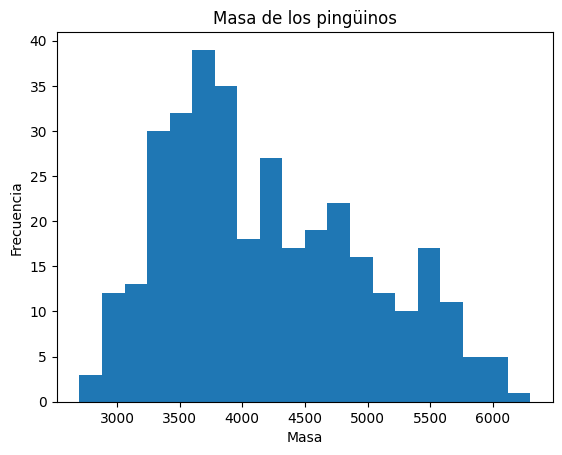

In [18]:
#histograma -> cuando la variable del eje x es cuantitativa -> campana de gauss = datos normales
plt.hist(df["body_mass_g"], bins=20)  #bins es en cuantas barras divide
#titulo
plt.title("Masa de los pingüinos")
plt.xlabel("Masa")
plt.ylabel("Frecuencia")

Text(0, 0.5, 'Frecuencia')

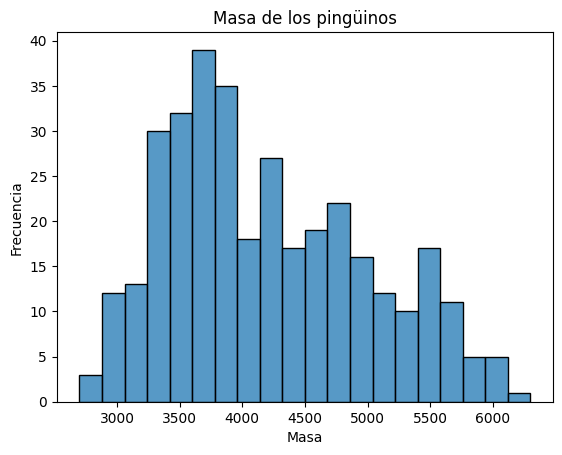

In [19]:
#histograma con sns
sns.histplot(df["body_mass_g"], bins=20)
plt.title("Masa de los pingüinos")
plt.xlabel("Masa")
plt.ylabel("Frecuencia")

Text(0, 0.5, 'Frecuencia')

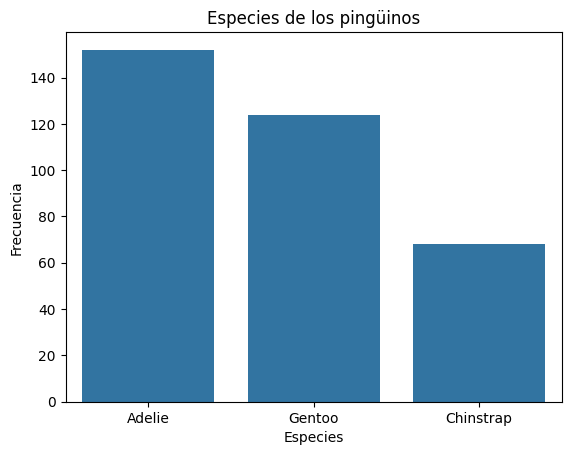

In [20]:
#gráfica de barras de especies de pinguinos -> variable x cuanlitativa
sns.countplot(x= df["species"], data=df)
plt.title("Especies de los pingüinos")
plt.xlabel("Especies")
plt.ylabel("Frecuencia")

Text(0, 0.5, 'masa del pinguino')

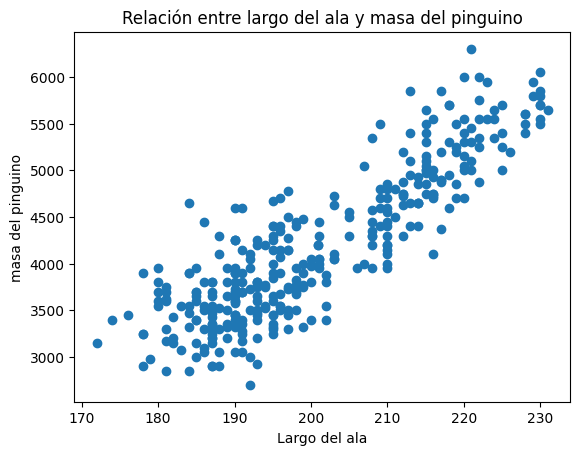

In [21]:
plt.scatter(df["flipper_length_mm"], df["body_mass_g"])
plt.title("Relación entre largo del ala y masa del pinguino")
plt.xlabel("Largo del ala")
plt.ylabel("masa del pinguino")
#x - y

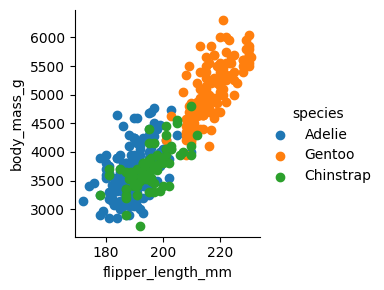

In [22]:
sns.FacetGrid(df, hue="species").map(plt.scatter, "flipper_length_mm", "body_mass_g").add_legend()
#FacetGrid es para dividir

<Axes: xlabel='species', ylabel='body_mass_g'>

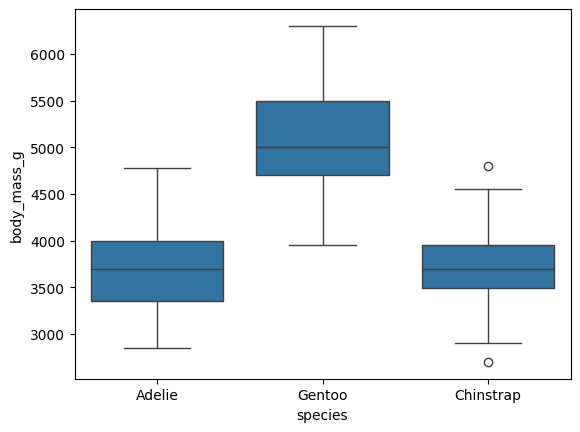

In [23]:
#gráfica de caja y bigote
sns.boxplot(x=df["species"], y=df["body_mass_g"])
#sns.boxplot(x='species', y= 'body_mass_g', data = df)
#UTILIZADAD -> Permite visualizar la distribución de la variable

# RANGO INTERCUARTIL (RI) = 1.5(Q3-Q1)

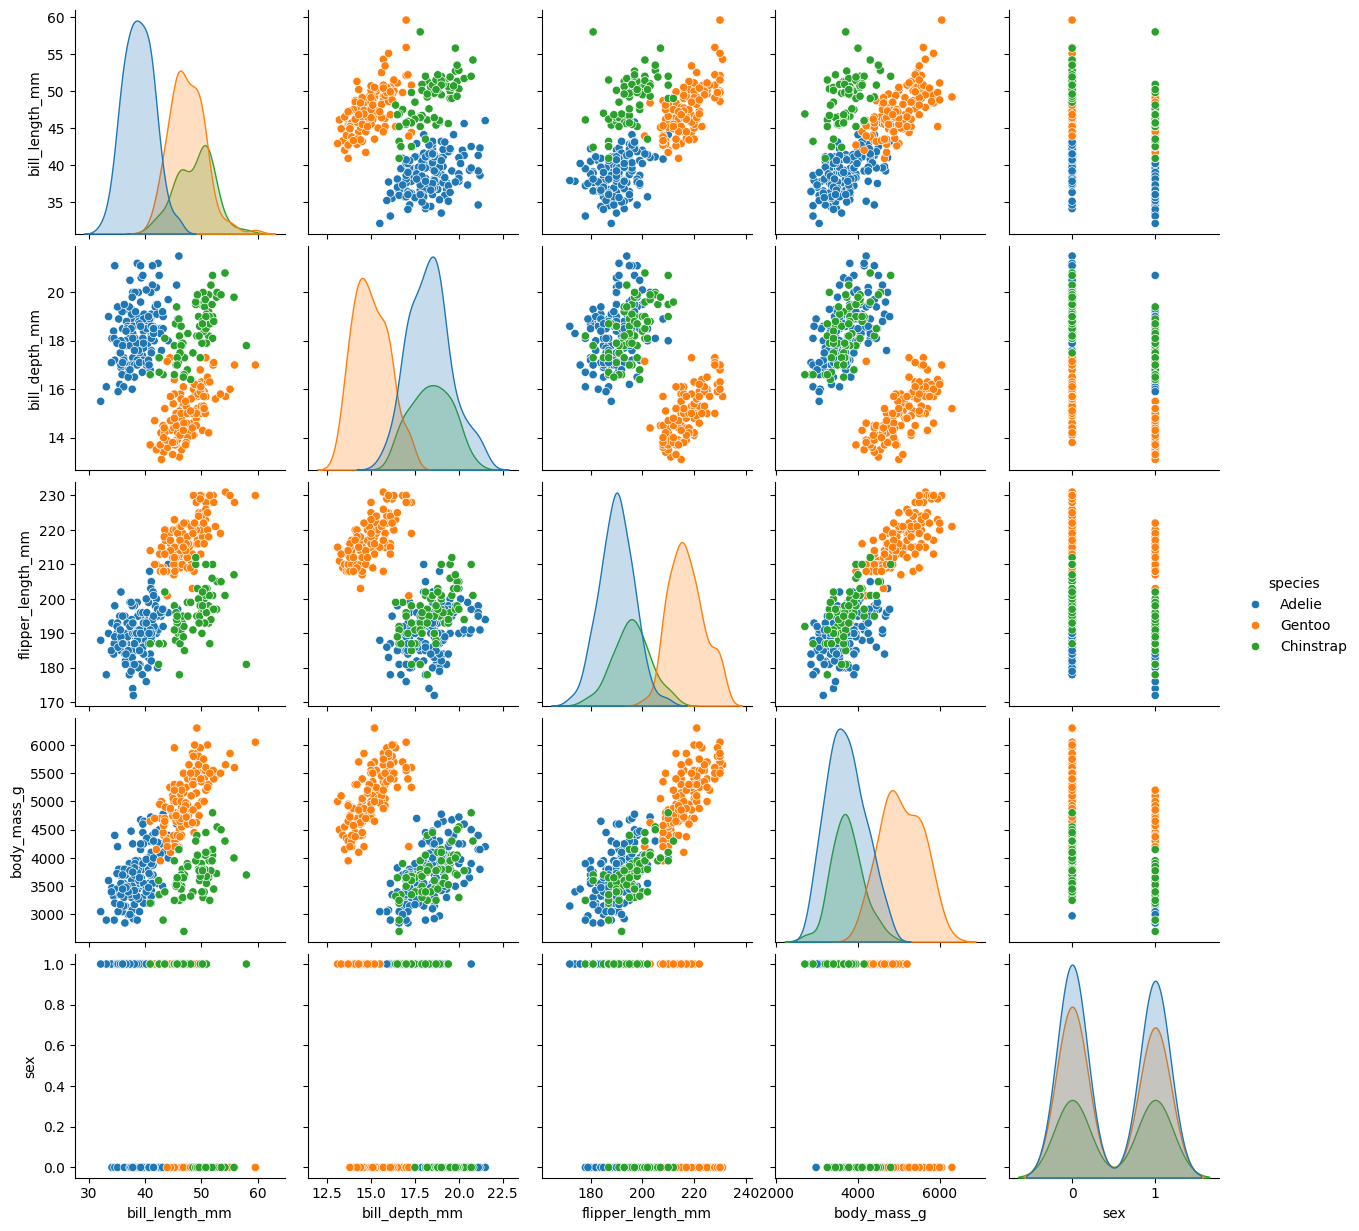

In [24]:
#SLV UN DIAGRAMA DE TODAS LAS VARIABLES CONGRA TODAS LAS VARIABLES
sns.pairplot(df, hue='species')  #dividirlo por especies

#las que no estén en la diagonal son disperción

<Axes: >

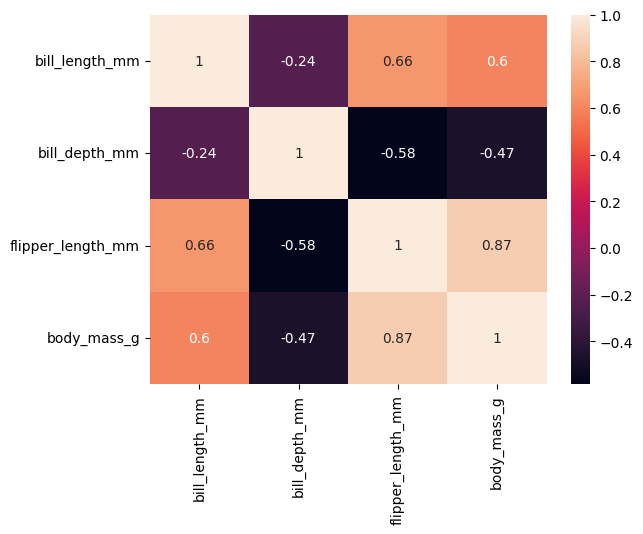

In [25]:
#correlaciones
#solo correlacionar las columnas que sea cuantitativas bill_lenght_mm, bill: depth, flippery body_mass
sns.heatmap(df[["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]].corr(), annot=True)

#agregar color -> cmap

In [26]:
#grafica de pastel
#primero el conteo -> la variable a la que pertenece -> graficarla
species=df['species'].value_counts()  #variable y conteo
species

,count
species,
Adelie,152
Gentoo,124
Chinstrap,68


In [27]:
island = df['island'].value_counts()
island

,count
island,
Biscoe,168
Dream,124
Torgersen,52


Text(0.5, 1.0, 'Distribución de Especies de los pingüinos')

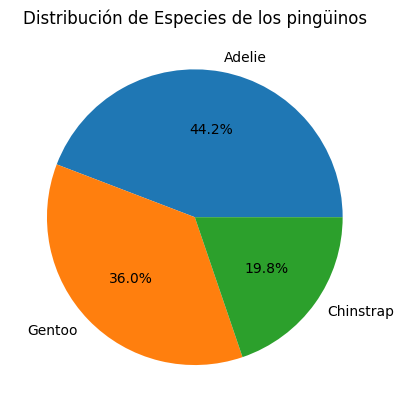

In [28]:
plt.pie(species, labels=species.index, autopct='%1.1f%%')
plt.title('Distribución de Especies de los pingüinos')
#presentacion de los decimales -> autopct='%1.1f%%'  -> expreción regular -> entero. 1 decimal flotante%